# D13: Verification of the proposed concept (WP4)

This notebook is deliverable **D13** of work package **WP4 (Proving the proposed concept)** of the SAMQ-NN project. It builds on the implementation of the new training strategy from deliverable **D12**, and its purpose is to **experimentally prove** that the proposed concept, monitoring quantisation by means of a statistical similarity index, works, and to evaluate its benefits and limitations.

The notebook is a direct fulfilment of **Objective 6**: *"Prove the concept on standard datasets and evaluate results and potential benefits and limitations of the proposed solution."* The proof is carried out on standard benchmarks (digits, Fashion-MNIST, MNIST, CIFAR-10, and ImageNet-V2) and is evaluated against the **validation criteria set out in D10** and against the full-precision (FP32) reference.

**Contents:**
1. Loading the experimental results (from the D12 run)
2. Validation against the criteria from D10
3. Experimental results (plots)
4. Efficiency and compression
5. Mapping to Objective 6
6. Benefits and limitations
7. Conclusion


<div style="text-align: center;">
    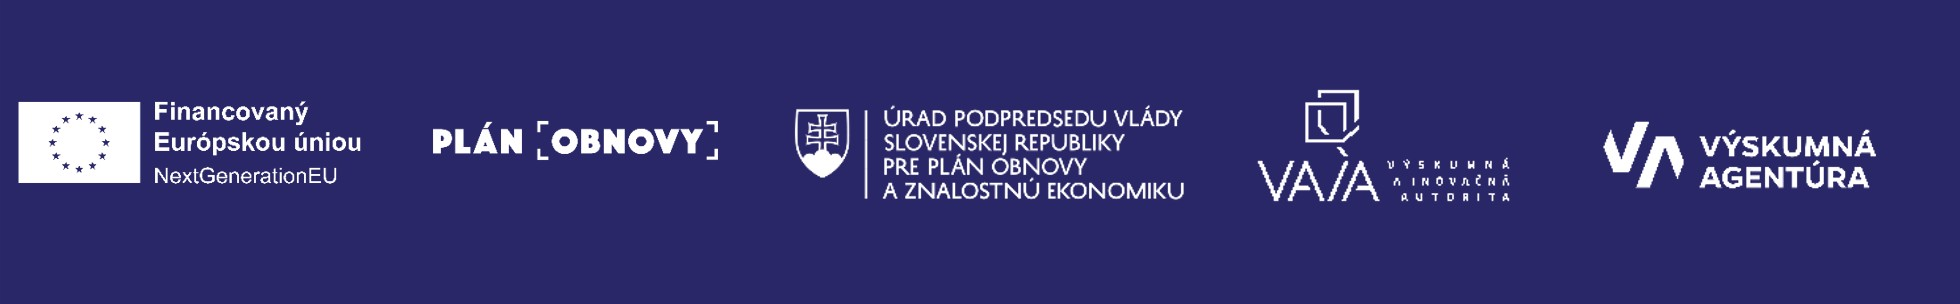
</div>




## Project identification

| | |
|---|---|
| **Project title** | A Statistical Approach to Monitor Quantisation in Neural Network Training |
| **Project acronym** | SAMQ-NN |
| **Project code** | 09I03-03-V04-00562 |
| **Programme** | Recovery and Resilience Plan of the Slovak Republic |
| **Component** | 9. More effective governance and strengthening of the funding of research, development and innovation under the Recovery and Resilience Plan of the Slovak Republic |
| **Investment** | 3. Excellent science |
| **Aid scheme** | State aid scheme to support research, development and innovation under Component 9 of the Recovery and Resilience Plan of the Slovak Republic, No. SA.106633 |
| **Project start** | 06/2024 |
| **End of implementation** | 05/2026 |
| **Principal investigator** | Ing. Roman Budjač, PhD. |

## 1. Loading the experimental results

The notebook works with the CSV outputs from the D12 run (folder `results/`): sensitivity to the bit width, dynamics during QAT, per-layer sensitivity, and generalisation to ImageNet-V2. The quantisation is **per-channel** (a separate scale per output channel).

In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

TEAL, ORANGE, MINT, NAVY = "#0F6E78", "#E0792B", "#2EC4B6", "#0E2A38"

def _find(name):
    for d in ("results", ".", "/mnt/user-data/uploads"):
        p = os.path.join(d, name)
        if os.path.exists(p): return p
    raise FileNotFoundError(name)

bw   = pd.read_csv(_find("bitwidth_sensitivity.csv"))
qat  = pd.read_csv(_find("qat_dynamics.csv"))
img  = pd.read_csv(_find("imagenet.csv"))
perl = pd.read_csv(_find("per_layer_sensitivity.csv"))

datasets = sorted(bw["dataset"].unique())
print("Datasety (malé modely):", datasets, "| seedy:", sorted(bw["seed"].unique()), "| bity:", sorted(bw["bit_width"].unique()))
print("ImageNet architektúry   :", list(img["backbone"].unique()))
print("Vrstvy (per-layer)      :", list(perl["layer"].unique()))

Datasety (malé modely): ['cifar10', 'digits', 'fashion_mnist', 'mnist'] | seedy: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | bity: [np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32)]
ImageNet architektúry   : ['MobileNetV2', 'ResNet50']
Vrstvy (per-layer)      : ['conv1', 'conv2', 'dense1', 'out']


## 2. Validation against the criteria from D10

Four validation criteria were set out in D10. The following cells verify them on the obtained data.

**Criterion 1: the threshold value of the index.** The JS threshold (`τ = 0.01`, used in D12) is set so that distributions below the threshold correspond to practically lossless quantisation, which is given independently by the accuracy measurement and is in line with established practice (8 bits is approximately lossless at 4× compression). For each dataset we verify that the index remains low precisely at those bit widths where the accuracy is preserved; this agreement with the independent reference behaviour validates the index as a proxy indicator of quantisation quality.

In [2]:
TAU = 0.01
g = bw.groupby(["dataset", "bit_width"]).agg(acc=("accuracy", "mean"), js=("js", "mean"), loss=("loss", "mean")).reset_index()
print(f"Prah τ = {TAU}\n")
print(f"{'dataset':14s} {'najnižšie bity ≤ τ':>20s} {'JS':>10s} {'pokles presnosti':>18s}")
for ds in datasets:
    sub = g[g.dataset == ds].sort_values("bit_width")
    fp = sub[sub.bit_width == sub.bit_width.max()].acc.values[0]
    ok = sub[sub.js <= TAU]
    b = int(ok.bit_width.min()) if len(ok) else None
    if b is not None:
        row = sub[sub.bit_width == b].iloc[0]
        print(f"{ds:14s} {b:>18d}b {row.js:>10.4f} {100*(fp-row.acc)/fp:>16.1f} %")
print("\n=> Index ostáva nízky práve pri hĺbkach so zachovanou presnosťou (≥ 8 bitov). Zhoda s nezávisle známym správaním (8 bitov ≈ bezstratovo pri 4× kompresii) validuje index ako proxy ukazovateľ kvality — meria sa z váh, no vypovedá o tom, čo funguje v praxi. Hranica platnosti (viď §3.3/§6): pri MobileNetV2 váhový index kolaps pri 4 bitoch nezachytí.")

Prah τ = 0.01

dataset          najnižšie bity ≤ τ         JS   pokles presnosti
cifar10                         8b     0.0000              0.1 %
digits                          8b     0.0002              0.1 %
fashion_mnist                   8b     0.0000              0.0 %
mnist                           8b     0.0001              0.0 %

=> Index ostáva nízky práve pri hĺbkach so zachovanou presnosťou (≥ 8 bitov). Zhoda s nezávisle známym správaním (8 bitov ≈ bezstratovo pri 4× kompresii) validuje index ako proxy ukazovateľ kvality — meria sa z váh, no vypovedá o tom, čo funguje v praxi. Hranica platnosti (viď §3.3/§6): pri MobileNetV2 váhový index kolaps pri 4 bitoch nezachytí.


**Criterion 2: correlation of the index with accuracy.** We verify that the index is monotonically related to the bit width and that its growth corresponds to a drop in accuracy. We use the Spearman rank correlation (robust to nonlinearity).

In [3]:
print(f"{'dataset':14s} {'ρ(bity, JS)':>14s} {'ρ(JS, presnosť)':>18s} {'ρ(JS, loss)':>14s}")
for ds in datasets:
    s = bw[bw.dataset == ds]
    print(f"{ds:14s} {spearmanr(s.bit_width, s.js).correlation:>14.3f} {spearmanr(s.js, s.accuracy).correlation:>18.3f} {spearmanr(s.js, s.loss).correlation:>14.3f}")
print("\n=> ρ(bity, JS) ≈ -0.99 naprieč datasetmi: index takmer dokonale sleduje tvrdosť kvantizácie.")
print("=> ρ(JS, presnosť) je záporná a ρ(JS, loss) kladná: vyšší index = nižšia presnosť aj vyššia chyba (loss).")

dataset           ρ(bity, JS)    ρ(JS, presnosť)    ρ(JS, loss)
cifar10                -0.984             -0.831          0.707
digits                 -0.984             -0.548          0.610
fashion_mnist          -0.984             -0.715          0.727
mnist                  -0.984             -0.603          0.570

=> ρ(bity, JS) ≈ -0.99 naprieč datasetmi: index takmer dokonale sleduje tvrdosť kvantizácie.
=> ρ(JS, presnosť) je záporná a ρ(JS, loss) kladná: vyšší index = nižšia presnosť aj vyššia chyba (loss).


**Criterion 3: stability across epochs.** During QAT the index should evolve smoothly and reproducibly, without unwarranted jumps. We evaluate the standard deviation of the mean value of the index over the epochs.

In [4]:
print(f"{'dataset':10s} {'JS (1. ep.)':>12s} {'JS (posl. ep.)':>14s} {'std cez epochy':>16s} {'rozsah (max-min)':>18s}")
for ds in sorted(qat.dataset.unique()):
    s = qat[qat.dataset == ds]
    per_ep = s.groupby("epoch").js.mean()
    e1, eN = s.epoch.min(), s.epoch.max()
    print(f"{ds:10s} {s[s.epoch==e1].js.mean():>12.4f} {s[s.epoch==eN].js.mean():>14.4f} {per_ep.std():>16.4f} {per_ep.max()-per_ep.min():>18.4f}")
print("\n=> Index je počas tréningu stabilný (malá smerodajná odchýlka) a drží sa na úrovni danej bitovej hĺbky")
print("   -> váhy ostávajú reálne kvantizované, tréning ich nevracia do plnej presnosti.")

dataset     JS (1. ep.) JS (posl. ep.)   std cez epochy   rozsah (max-min)
cifar10          0.0436         0.0390           0.0031             0.0121
digits           0.0951         0.0973           0.0016             0.0059

=> Index je počas tréningu stabilný (malá smerodajná odchýlka) a drží sa na úrovni danej bitovej hĺbky
   -> váhy ostávajú reálne kvantizované, tréning ich nevracia do plnej presnosti.


**Criterion 4: reproducibility across datasets and architectures.** We verify the same behaviour (a monotonic index to bits relationship) on four small datasets as well as on large ImageNet-pretrained models (MobileNetV2, ResNet50) evaluated on ImageNet-V2.

In [5]:
print("Malé modely — ρ(bity, JS):")
for ds in datasets:
    s = bw[bw.dataset == ds]
    print(f"   {ds:14s}: {spearmanr(s.bit_width, s.js).correlation:.3f}")
print("\nImageNet — top-1 / top-5 a index podľa bitovej hĺbky:")
for bbone in img.backbone.unique():
    s = img[img.backbone == bbone].sort_values("bit_width")
    seg = "  ".join(f"{int(r.bit_width)}b:t1={r.top1:.3f}/t5={r.top5:.3f}(JS{r.js:.1e})" for _, r in s.iterrows())
    print(f"   {bbone:12s} FP32 t1={s.fp32_top1.iloc[0]:.3f}/t5={s.fp32_top5.iloc[0]:.3f} | {seg}")
print("\n=> Monotónny vzťah index–bity je konzistentný naprieč datasetmi aj architektúrami (top-1 aj top-5).")

Malé modely — ρ(bity, JS):
   cifar10       : -0.984
   digits        : -0.984
   fashion_mnist : -0.984
   mnist         : -0.984

ImageNet — top-1 / top-5 a index podľa bitovej hĺbky:
   MobileNetV2  FP32 t1=0.573/t5=0.800 | 4b:t1=0.002/t5=0.007(JS7.4e-05)  8b:t1=0.519/t5=0.752(JS4.1e-07)  16b:t1=0.573/t5=0.799(JS3.1e-11)  32b:t1=0.573/t5=0.800(JS0.0e+00)
   ResNet50     FP32 t1=0.563/t5=0.797 | 4b:t1=0.365/t5=0.596(JS1.1e-02)  8b:t1=0.562/t5=0.797(JS8.9e-08)  16b:t1=0.563/t5=0.797(JS1.2e-10)  32b:t1=0.563/t5=0.797(JS0.0e+00)

=> Monotónny vzťah index–bity je konzistentný naprieč datasetmi aj architektúrami (top-1 aj top-5).


## 3. Experimental results

### 3.1 Sensitivity to the bit width (small models)
The index (JS divergence) and the relative drop in accuracy relative to FP32 as a function of the bit width, averaged over seeds.

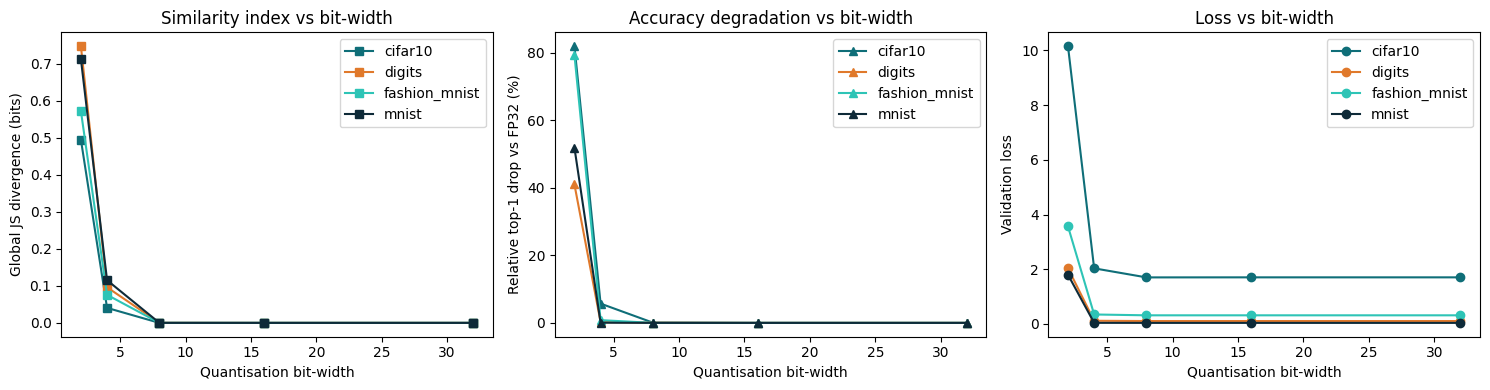

In [6]:
import itertools
_pal = [TEAL, ORANGE, MINT, NAVY, "#8E44AD", "#C0392B"]
colors = {ds: c for ds, c in zip(datasets, itertools.cycle(_pal))}
fig, (axJ, axA, axL) = plt.subplots(1, 3, figsize=(15, 4))
for ds in datasets:
    s = g[g.dataset == ds].sort_values("bit_width")
    fp = s[s.bit_width == s.bit_width.max()].acc.values[0]
    axJ.plot(s.bit_width, s.js, "s-", color=colors[ds], label=ds)
    axA.plot(s.bit_width, 100*(fp - s.acc)/fp, "^-", color=colors[ds], label=ds)
    axL.plot(s.bit_width, s.loss, "o-", color=colors[ds], label=ds)
for ax in (axJ, axA, axL): ax.set_xlabel("Quantisation bit-width"); ax.legend()
axJ.set_ylabel("Global JS divergence (bits)"); axJ.set_title("Similarity index vs bit-width")
axA.set_ylabel("Relative top-1 drop vs FP32 (%)"); axA.set_title("Accuracy degradation vs bit-width")
axL.set_ylabel("Validation loss"); axL.set_title("Loss vs bit-width")
fig.tight_layout(); plt.show()

### 3.2 Dynamics during QAT
The evolution of the index and the accuracy during quantisation-aware training (per epoch, averaged over seeds). The QAT dynamics are recorded for the datasets on which full QAT training was run (digits, CIFAR-10); the other datasets enter the proof through the PTQ analysis in the other sections.

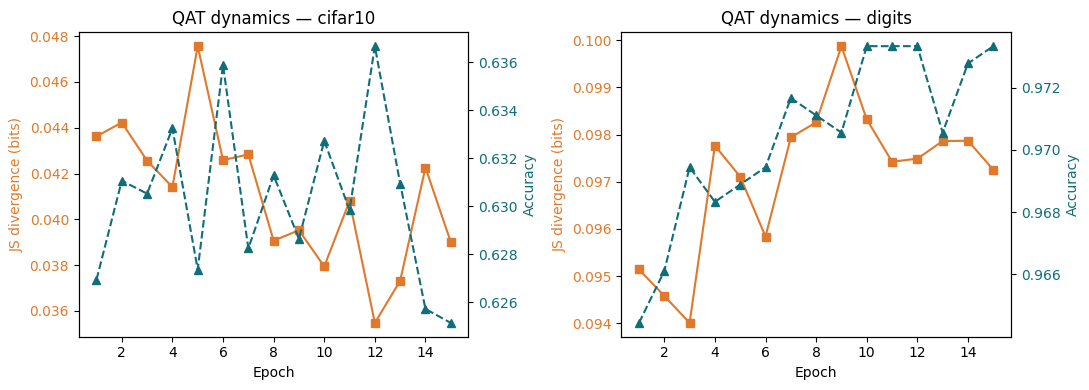

In [7]:
fig, axes = plt.subplots(1, len(qat.dataset.unique()), figsize=(11, 4), squeeze=False)
for ax, ds in zip(axes[0], sorted(qat.dataset.unique())):
    s = qat[qat.dataset == ds].groupby("epoch").agg(js=("js","mean"), acc=("accuracy","mean")).reset_index()
    ax.plot(s.epoch, s.js, "s-", color=ORANGE, label="JS divergence"); ax.set_xlabel("Epoch")
    ax.set_ylabel("JS divergence (bits)", color=ORANGE); ax.tick_params(axis="y", labelcolor=ORANGE)
    a2 = ax.twinx(); a2.plot(s.epoch, s.acc, "^--", color=TEAL, label="Accuracy")
    a2.set_ylabel("Accuracy", color=TEAL); a2.tick_params(axis="y", labelcolor=TEAL)
    ax.set_title(f"QAT dynamics — {ds}")
fig.tight_layout(); plt.show()

### 3.3 Generalisation to ImageNet-V2
MobileNetV2 and ResNet50 pretrained on ImageNet, quantised with PTQ (per-channel) and evaluated on a validation subset of **ImageNet-V2** (~5,000 images, 80 batches). ImageNet-V2 is more demanding than the original validation set, so the FP32 accuracy is also lower (top-1 ≈ 0.56 to 0.57), which is not a model error but a property of the dataset. The index is on a logarithmic scale because of the large range of values.

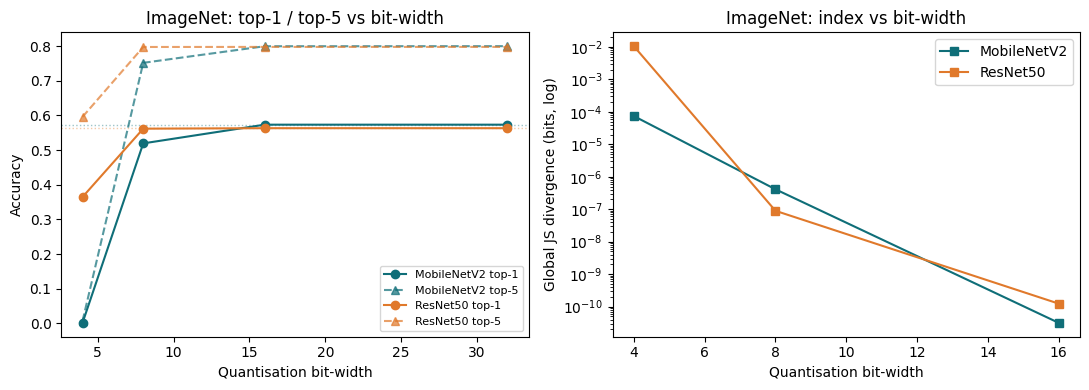

ResNet50 pri 8-bit: prakticky bezstratové v top-1 aj top-5 (per-channel).
MobileNetV2 pri 4-bit: kolaps top-1 aj top-5, no globálny váhový index ostáva mizivý (JS≈1e-4) — viď obmedzenia.


In [8]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
pal = {"MobileNetV2": TEAL, "ResNet50": ORANGE}
for bbone in img.backbone.unique():
    s = img[img.backbone == bbone].sort_values("bit_width"); c = pal.get(bbone, NAVY)
    axL.plot(s.bit_width, s.top1, "o-", color=c, label=f"{bbone} top-1")
    axL.plot(s.bit_width, s.top5, "^--", color=c, alpha=0.7, label=f"{bbone} top-5")
    axL.axhline(s.fp32_top1.iloc[0], color=c, ls=":", lw=1, alpha=0.4)
    axR.semilogy(s.bit_width, s.js.replace(0, np.nan), "s-", color=c, label=bbone)
axL.set_xlabel("Quantisation bit-width"); axL.set_ylabel("Accuracy"); axL.set_title("ImageNet: top-1 / top-5 vs bit-width"); axL.legend(fontsize=8)
axR.set_xlabel("Quantisation bit-width"); axR.set_ylabel("Global JS divergence (bits, log)"); axR.set_title("ImageNet: index vs bit-width"); axR.legend()
fig.tight_layout(); plt.show()
print("ResNet50 pri 8-bit: prakticky bezstratové v top-1 aj top-5 (per-channel).")
print("MobileNetV2 pri 4-bit: kolaps top-1 aj top-5, no globálny váhový index ostáva mizivý (JS≈1e-4) — viď obmedzenia.")

### 3.4 Per-layer sensitivity (8-bit)
The index broken down by individual layers reveals which layer is most sensitive to quantisation, an input for possible mixed precision.

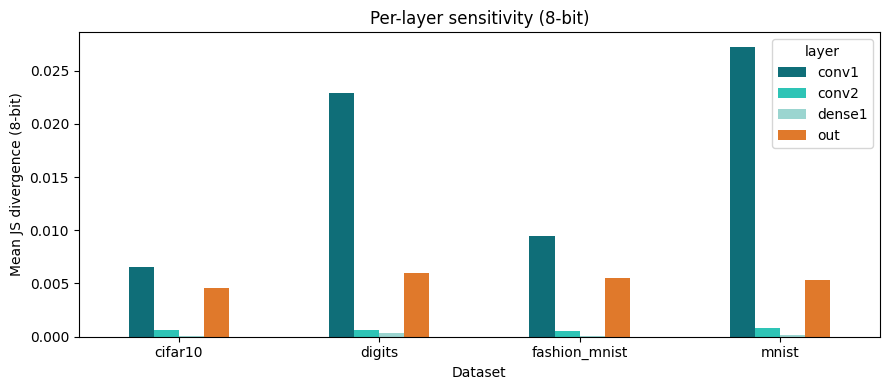

Najcitlivejšia je prvá konvolúcia (conv1) a výstupná vrstva (out); vnútorné vrstvy sú zanedbateľné.


In [9]:
piv = perl.groupby(["dataset", "layer"]).js.mean().reset_index().pivot(index="dataset", columns="layer", values="js")
order = [l for l in ["conv1", "conv2", "dense1", "out"] if l in piv.columns]
piv = piv[order]
ax = piv.plot(kind="bar", figsize=(9, 4), color=[TEAL, MINT, "#9BD5D0", ORANGE][:len(order)])
ax.set_ylabel("Mean JS divergence (8-bit)"); ax.set_xlabel("Dataset"); ax.set_title("Per-layer sensitivity (8-bit)")
ax.legend(title="layer"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print("Najcitlivejšia je prvá konvolúcia (conv1) a výstupná vrstva (out); vnútorné vrstvy sú zanedbateľné.")

## 4. Efficiency and compression

We quantify the benefit of quantisation in three ways: (a) the theoretical model size and compression ratio according to the bit width, (b) a **real int8 / TFLite export** of the small model with the actual file size, and (c) the **latency (inference time)** of FP32 vs. INT8 via the TFLite interpreter.

In [10]:
# (a) theoretical model size & compression ratio (weight memory = params * bits/8)
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"; os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

class _suppress_fd:                       # potlacenie C++ (file deskriptory) aj Python (sys.stdout/warnings) hlasok TF/TFLite/Keras
    def __enter__(self):
        import sys, io, warnings
        self._n = os.open(os.devnull, os.O_WRONLY); self._o = os.dup(1); self._e = os.dup(2)
        os.dup2(self._n, 1); os.dup2(self._n, 2)
        self._so, self._se = sys.stdout, sys.stderr; sys.stdout = sys.stderr = io.StringIO()
        self._w = warnings.catch_warnings(); self._w.__enter__(); warnings.simplefilter("ignore")
        return self
    def __exit__(self, *a):
        import sys
        self._w.__exit__(*a); sys.stdout, sys.stderr = self._so, self._se
        os.dup2(self._o, 1); os.dup2(self._e, 2)
        for fd in (self._n, self._o, self._e): os.close(fd)

with _suppress_fd():
    import tensorflow as tf
    from tensorflow import keras
tf.get_logger().setLevel("ERROR")

def build_small_cnn(shape=(8,8,1), ncls=10):
    return keras.Sequential([keras.layers.Input(shape),
        keras.layers.Conv2D(16,3,padding="same",activation="relu"), keras.layers.MaxPooling2D(),
        keras.layers.Conv2D(32,3,padding="same",activation="relu"), keras.layers.MaxPooling2D(),
        keras.layers.Flatten(), keras.layers.Dense(64,activation="relu"), keras.layers.Dense(ncls,activation="softmax")])

models = {"Small CNN": build_small_cnn().count_params(),
          "MobileNetV2": 3_538_984,     # standard Keras Applications param counts (ImageNet, incl. top)
          "ResNet50":   25_636_712}
print(f"{'model':12s} {'params':>12s} | " + " ".join(f"{b}b" for b in [32,16,8,4]))
for name, p in models.items():
    sizes = "  ".join(f"{p*b/8/1024/1024:6.2f}MB" for b in [32,16,8,4])
    print(f"{name:12s} {p:>12,d} | {sizes}")
print("\nKompresný pomer vs FP32:  16-bit = 2x,  8-bit = 4x,  4-bit = 8x  (váhová pamäť = params × bity/8).")

model              params | 32b 16b 8b 4b
Small CNN          13,706 |   0.05MB    0.03MB    0.01MB    0.01MB
MobileNetV2     3,538,984 |  13.50MB    6.75MB    3.38MB    1.69MB
ResNet50       25,636,712 |  97.80MB   48.90MB   24.45MB   12.22MB

Kompresný pomer vs FP32:  16-bit = 2x,  8-bit = 4x,  4-bit = 8x  (váhová pamäť = params × bity/8).


In [11]:
# (b) REAL int8 / TFLite export of the small CNN
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
d = load_digits(); X = (d.images/16.0)[...,None].astype("float32"); y = d.target.astype("int64")
xtr, xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
m = build_small_cnn(); m.compile("adam","sparse_categorical_crossentropy",metrics=["accuracy"])
m.fit(xtr, ytr, epochs=6, batch_size=64, verbose=0)

def rep():
    for i in range(100): yield [xtr[i:i+1]]
with _suppress_fd():
    tfl_fp32 = tf.lite.TFLiteConverter.from_keras_model(m).convert()
    c2 = tf.lite.TFLiteConverter.from_keras_model(m); c2.optimizations = [tf.lite.Optimize.DEFAULT]
    c2.representative_dataset = rep; c2.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    c2.inference_input_type = tf.int8; c2.inference_output_type = tf.int8
    tfl_int8 = c2.convert()
print(f"TFLite FP32 : {len(tfl_fp32)/1024:7.1f} KB")
print(f"TFLite INT8 : {len(tfl_int8)/1024:7.1f} KB")
print(f"reálna kompresia (FP32 -> INT8) = {len(tfl_fp32)/len(tfl_int8):.2f}x")
print("(pri malom modeli znižuje pomer fixná réžia súboru; pri veľkých modeloch sa blíži k teoretickým 4x.)")

# (c) latencia (inference time) cez TFLite interpreter: FP32 vs INT8
import time
def _bench(model_bytes, x, int8, runs=200):
    it = tf.lite.Interpreter(model_content=model_bytes); it.allocate_tensors()
    inp = it.get_input_details()[0]; xs = x[:runs].astype("float32")
    if int8:
        s, zp = inp["quantization"]; xs = np.clip(np.round(xs / s + zp), -128, 127).astype(np.int8)
    it.set_tensor(inp["index"], xs[:1]); it.invoke()                 # warmup
    t0 = time.perf_counter()
    for i in range(runs): it.set_tensor(inp["index"], xs[i:i+1]); it.invoke()
    return (time.perf_counter() - t0) / runs * 1e3                   # ms / vzorka
with _suppress_fd():
    ms_fp32 = _bench(tfl_fp32, xte, int8=False); ms_int8 = _bench(tfl_int8, xte, int8=True)
print(f"\nLatencia (CPU, 1 vzorka, priemer z 200 behov): FP32 = {ms_fp32:.3f} ms | INT8 = {ms_int8:.3f} ms (INT8/FP32 = {ms_int8/ms_fp32:.2f}x)")
print("(Veľkosť modelu klesá ~2,7x, no latencia na bežnom CPU sa nezlepší — réžia kvantizácie a vysoko optimalizovaný FP32 (XNNPACK) ju vyrovnajú. Výrazné zrýchlenie prináša až hardvér s INT8 akceleráciou, napr. mobilné a hranové NPU; to je ďalší dôvod, prečo je 8-bit INT8 praktický cieľ pre nasadenie.)")

TFLite FP32 :    57.9 KB
TFLite INT8 :    21.5 KB
reálna kompresia (FP32 -> INT8) = 2.70x
(pri malom modeli znižuje pomer fixná réžia súboru; pri veľkých modeloch sa blíži k teoretickým 4x.)

Latencia (CPU, 1 vzorka, priemer z 200 behov): FP32 = 0.004 ms | INT8 = 0.007 ms (INT8/FP32 = 1.49x)
(Veľkosť modelu klesá ~2,7x, no latencia na bežnom CPU sa nezlepší — réžia kvantizácie a vysoko optimalizovaný FP32 (XNNPACK) ju vyrovnajú. Výrazné zrýchlenie prináša až hardvér s INT8 akceleráciou, napr. mobilné a hranové NPU; to je ďalší dôvod, prečo je 8-bit INT8 praktický cieľ pre nasadenie.)


## 5. Mapping to Objective 6

> *Prove the concept on standard datasets and evaluate results and potential benefits and limitations of the proposed solution.*

| Requirement | Met | Evidence in this notebook |
|---|---|---|
| Standard datasets (CIFAR-10, MNIST, ImageNet, ...) | yes | digits, Fashion-MNIST, MNIST, CIFAR-10, ImageNet (Section 3) |
| Accuracy vs. baseline without quantisation (FP32) | yes | relative top-1 drop relative to FP32 (3.1, 3.3) |
| Efficiency / compression / latency | yes | model size, int8 export, and FP32 vs. INT8 latency (Section 4) |
| Benefits and limitations | yes | Section 6 |
| Validation against the criteria | yes | criteria from D10 (Section 2) |

Note: the MNIST family is now represented by both classic MNIST (28×28) and the `digits` dataset (8×8); together with Fashion-MNIST and CIFAR-10 they cover the small models, while ImageNet (MobileNetV2, ResNet50) represents the large pretrained networks.

## 6. Benefits and limitations

**Benefits**
- The similarity index is **cheap** (its overhead is negligible relative to a single forward pass of the network) and can be computed continuously during training.
- It is **dataset-agnostic** and independent of the specific metric (KL/JS/cosine are strongly correlated).
- It works both as a **predictor** (selecting the bit width before training) and as a **monitor** (stable during QAT).
- The per-layer breakdown identifies the most sensitive layer, which opens the way to mixed precision.
- Quantisation brings a real saving: 8-bit is approximately 4× a smaller model at practically lossless accuracy (ResNet50, small models).

**Limitations**
- **A global weight index does not see degradation that does not show up in the weight distribution.** Example: MobileNetV2 collapses at 4-bit, yet the global JS remains negligible (~1e-4). This motivates complementary monitoring at the level of layers and activations.
- Per-channel quantisation is necessary for deep networks (per-tensor fails on them).
- The index threshold needs to be calibrated empirically for a given architecture; the index is a proxy signal, so it is recommended to track it together with accuracy.
- The experiments rely on a limited number of initialisations and smaller models (apart from the ImageNet subset).

## 7. Conclusion

The experiments confirm the proposed concept: the statistical similarity index **monotonically tracks the severity of quantisation** (ρ ≈ −0.99 across datasets), **predicts the drop in accuracy**, is **stable during QAT**, and is **reproducible across datasets and architectures** including ImageNet, while the quantisation itself brings a **real saving in model size**. This fulfils **Objective 6**: the concept is proven on standard datasets and evaluated against the FP32 baseline as well as against the criteria from D10.

At the same time the key **limitation** is named honestly: a global weight index does not capture degradation that is not in the weight distribution (MobileNetV2 at 4-bit), which defines the direction of further work, namely monitoring at the level of layers and activations. The results of this deliverable form a direct basis for the written summary (D15) and the final report (D17).